<a href="https://colab.research.google.com/github/gokulgovindtk/R-D-engineer-path/blob/main/1D_wave_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

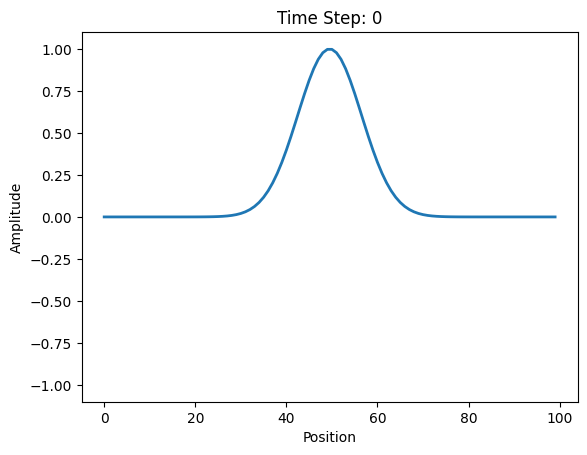

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def apply_bc(u):
    u[0] = 0.0
    u[-1] = 0.0

def solve_wave(nx=100, Lx=1, c=10, dt=0.0005, nt=800):
    dx = Lx / (nx - 1)
    dt_max = dx / c

    if dt > dt_max:
        # Automatically adjust dt if it's unstable
        dt = dt_max * 0.9
        print(f"dt was too large. Adjusted to: {dt:.4e}")

    # Courant number squared
    C2 = (c * dt / dx)**2

    # Initial displacement: Using a Gaussian pulse for a smoother wave
    x = np.linspace(0, Lx, nx)
    u_curr = np.exp(-100 * (x - Lx/2)**2)
    u_prev = u_curr.copy() # Assuming initial velocity = 0

    history = [u_curr.copy()]

    # Time-stepping loop
    for n in range(nt):
        u_next = np.zeros(nx)

        # Finite Difference Calculation
        for i in range(1, nx-1):
            u_next[i] = (2 * u_curr[i] - u_prev[i] +
                         C2 * (u_curr[i+1] - 2 * u_curr[i] + u_curr[i-1]))

        apply_bc(u_next)
        history.append(u_next.copy())

        # Update states for next iteration
        u_prev = u_curr.copy()
        u_curr = u_next.copy()

    return np.array(history)

def animate_solution(history):
    fig, ax = plt.subplots()
    line, = ax.plot(history[0], lw=2)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amplitude")

    def update(frame):
        line.set_ydata(history[frame])
        ax.set_title(f"Time Step: {frame}")
        return line,

    anim = FuncAnimation(fig, update, frames=len(history), interval=15, blit=True)
    plt.show()

# Run the simulation
history = solve_wave()
animate_solution(history)






